<a href="https://www.kaggle.com/code/zoroxide/computer-hardware-scraping-in-egypt?scriptVersionId=237475340" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Computer Hardware Scrapping in Egypt 💻🖥️

### included: 
- OLX EG (dubizzle now)
- Amazon.eg
- Sigma PC

### **in this exmaples we are scraping the RTX Graphics Cards , you can scrap anything you like e.g: *rx580****

# 1. installing Dependeces

### I Used ``` aiohttp asyncio httpx ``` for faster and correct use of high speed and precise scrappers

In [47]:
%pip install aiohttp asyncio httpx

Note: you may need to restart the kernel to use updated packages.


In [48]:
import aiohttp
import asyncio
from bs4 import BeautifulSoup
import re
import pandas as pd
import nest_asyncio
from typing import List, Dict, Any, Optional
import httpx
import random
import seaborn as sns
import matplotlib.pyplot as plt


# Allows running async functions in Jupyter notebooks
nest_asyncio.apply() 

# Number of concurrent requests
CONCURRENT_REQUESTS = 10

BATCH_SIZE = 10

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:109.0) Gecko/20100101 Firefox/109.0",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,*/*;q=0.8",
    "Accept-Language": "en-US,en;q=0.5",
    "Accept-Encoding": "gzip, deflate, br",
    "Connection": "keep-alive",
}

# OLX Scraper

In [49]:
class OLX_Spyder:
    def __init__(self, search_term: str):
        self.search_term = search_term.replace(' ', '-')
        self.base_search_url = f"https://www.dubizzle.com.eg/en/electronics-home-appliances/computers-accessories/q-{self.search_term}"

    async def fetch_page(self, session: aiohttp.ClientSession, url: str, page: int) -> str:
        try:
            async with session.get(url, headers=HEADERS) as response:
                if response.status != 200:
                    print(f"Failed to fetch page {page}. Status: {response.status}")
                    return ""
                return await response.text()
        except Exception as e:
            print(f"Error fetching page {page}: {str(e)}")
            return ""

    def parse_page(self, html: str, page: int) -> List[Dict[str, Any]]:
        soup = BeautifulSoup(html, 'html.parser')
        data_list = []
        listings = soup.find_all('li', attrs={'aria-label': 'Listing'})

        for listing in listings:
            title_tag = listing.find('h2', class_='_941ffa5e')
            price_tag = listing.find('span', class_='_1f2a2b47')
            location_tag = listing.find('span', class_='_77000f35')
            image_tag = listing.find('img', class_='f79152f1')
            link_tag = listing.find('a', href=True)

            details_link = "https://www.dubizzle.com.eg" + link_tag['href'] if link_tag else "N/A"
            product_id = re.search(r'-ID(\d+)', link_tag['href']).group(1) if link_tag else "N/A"

            data_list.append({
                "Product ID": product_id,
                "Title": title_tag.text.strip() if title_tag else "N/A",
                "Price": price_tag.text.strip() if price_tag else "N/A",
                "Location": location_tag.text.strip() if location_tag else "N/A",
                "Details Link": details_link,
                "Image URL": image_tag['src'] if image_tag else "N/A",
                "Page": page
            })

        print(f"Found {len(data_list)} listings on page {page}")
        return data_list

    async def scrape_olx_async(self) -> List[Dict[str, Any]]:
        async with aiohttp.ClientSession() as session:
            first_page_html = await self.fetch_page(session, self.base_search_url, 1)
            if not first_page_html:
                return []

            all_html_pages = [first_page_html]
            current_page = 2

            while True:
                batch_tasks = [
                    self.fetch_page(session, f"{self.base_search_url}/?page={page_num}", page_num)
                    for page_num in range(current_page, current_page + BATCH_SIZE)
                ]
                batch_results = await asyncio.gather(*batch_tasks)
                all_html_pages.extend(filter(None, batch_results))
                if not any(batch_results):
                    break
                current_page += BATCH_SIZE
                if current_page > 50:
                    break

            all_results = []
            for page_num, html in enumerate(all_html_pages, start=1):
                all_results.extend(self.parse_page(html, page_num))
            return all_results

    async def scrape(self) -> List[Dict[str, Any]]:
        return await self.scrape_olx_async()

In [50]:
async def run_scraper(search_term: str):
        spyder = OLX_Spyder(search_term)
        results = await spyder.scrape()
        df = pd.DataFrame(results)
        return df
olx_df = asyncio.get_event_loop().run_until_complete(run_scraper("rtx"))
olx_df.head()

Failed to fetch page 9. Status: 404
Failed to fetch page 10. Status: 404
Failed to fetch page 11. Status: 404
Failed to fetch page 15. Status: 404
Failed to fetch page 21. Status: 404
Failed to fetch page 19. Status: 404
Failed to fetch page 12. Status: 404
Failed to fetch page 17. Status: 404
Failed to fetch page 18. Status: 404
Failed to fetch page 13. Status: 404
Failed to fetch page 16. Status: 404
Failed to fetch page 20. Status: 404
Failed to fetch page 14. Status: 404
Found 45 listings on page 1
Found 45 listings on page 2
Found 45 listings on page 3
Found 45 listings on page 4
Found 45 listings on page 5
Found 45 listings on page 6
Found 45 listings on page 7
Found 16 listings on page 8


,Product ID,Title,Price,Location,Details Link,Image URL,Page
0,204288076,Gaming Laptop RTX 4090,"EGP 100,000","Maadi, Cairo•",https://www.dubizzle.com.eg/en/ad/gaming-lapto...,https://images.dubizzle.com.eg/thumbnails/1392...,1
1,204532227,alienware area 51m Rtx 2080 215 واط & i9 9900k...,"EGP 65,000","Hadayek al-Kobba, Cairo•",https://www.dubizzle.com.eg/en/ad/alienware-ar...,https://images.dubizzle.com.eg/thumbnails/1411...,1
2,204561978,gaming pc i5 10th Gen with RTX 3060 12 gb,"EGP 26,000","Almazah, Cairo•",https://www.dubizzle.com.eg/en/ad/gaming-pc-i5...,https://images.dubizzle.com.eg/thumbnails/1411...,1
3,204498905,ASUS TUF Gaming RTX 4050 Ryzen 7 7735hs laptop,"EGP 45,000","Gesr Al Suez, Cairo•",https://www.dubizzle.com.eg/en/ad/asus-tuf-gam...,https://images.dubizzle.com.eg/thumbnails/1406...,1
4,204048051,HP ZBOOK 15 G6 RTX 3000 6G,"EGP 26,000","New Cairo, Cairo•",https://www.dubizzle.com.eg/en/ad/hp-zbook-15-...,https://images.dubizzle.com.eg/thumbnails/1375...,1


# Amazon.eg Scraper

In [51]:
USER_AGENTS = [
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/102.0.5005.61 Safari/537.36",
    "Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:92.0) Gecko/20100101 Firefox/92.0",
    "Mozilla/5.0 (Windows NT 10.0; rv:91.0) Gecko/20100101 Firefox/91.0",
]

class AmazonSpyder:
    def __init__(self):
        self.headers = {
            "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,*/*;q=0.8",
            "Accept-Language": "en-US,en;q=0.5",
            "Accept-Encoding": "gzip, deflate, br",
            "Connection": "keep-alive",
        }
        self.semaphore = asyncio.Semaphore(CONCURRENT_REQUESTS)  # Limit concurrency

    async def fetch_page(self, client: httpx.AsyncClient, search_term: str, page: int) -> Optional[List[Dict[str, Any]]]:
        """Fetch a single page and parse results."""
        async with self.semaphore:
            url = f"https://www.amazon.eg/s?k={search_term}&language=en&page={page}"
            self.headers["User-Agent"] = random.choice(USER_AGENTS)
            
            try:
                response = await client.get(url, headers=self.headers)
                if response.status_code == 404:
                    print(f"Page {page} not found (404).")
                    return None

                if response.status_code != 200:
                    print(f"Failed to fetch page {page}. Status: {response.status_code}")
                    return []

                html = response.text
                soup = BeautifulSoup(html, "html.parser")

                # Parse product data
                product_cards = soup.select("div[data-component-type='s-search-result']")
                products = []
                for card in product_cards:
                    try:
                        title = card.find("h2").text.strip() if card.find("h2") else "N/A"
                        link = f"https://www.amazon.eg{card.find('a')['href']}" if card.find("a") else None
                        price = card.select_one(".a-price-whole").text.strip() if card.select_one(".a-price-whole") else "N/A"
                        rating = card.select_one(".a-icon-alt").text.strip() if card.select_one(".a-icon-alt") else "N/A"
                        image = card.select_one("img")["src"] if card.select_one("img") else "N/A"

                        products.append({
                            "Title": title,
                            "Price": price,
                            "Rating": rating,
                            "Details Link": link,
                            "Image URL": image,
                            "Page": page,
                        })
                    except Exception:
                        continue

                print(f"Found {len(products)} products on page {page}.")
                return products

            except Exception as e:
                print(f"Error fetching page {page}: {str(e)}")
                return []

    async def scrap(self, search_term: str) -> List[Dict[str, Any]]:
        """Scrape products concurrently."""
        timeout = httpx.Timeout(30.0, connect=10.0)
        limits = httpx.Limits(max_connections=CONCURRENT_REQUESTS, max_keepalive_connections=20)

        async with httpx.AsyncClient(timeout=timeout, limits=limits) as client:
            tasks = [self.fetch_page(client, search_term, page) for page in range(1, 21)]
            all_results = await asyncio.gather(*tasks)

        # Flatten and filter results
        products = [product for result in all_results if result for product in result]
        return products

In [52]:
spyder = AmazonSpyder()
results = asyncio.run(spyder.scrap("rtx"))
amazon_df = pd.DataFrame(results)
amazon_df.head()

Failed to fetch page 1. Status: 503
Failed to fetch page 4. Status: 503
Failed to fetch page 6. Status: 503
Failed to fetch page 7. Status: 503
Failed to fetch page 10. Status: 503
Failed to fetch page 5. Status: 503
Failed to fetch page 3. Status: 503
Failed to fetch page 8. Status: 503
Failed to fetch page 11. Status: 503
Failed to fetch page 12. Status: 503
Failed to fetch page 13. Status: 503
Found 0 products on page 9.
Found 0 products on page 17.
Found 0 products on page 19.
Found 0 products on page 18.
Found 48 products on page 2.
Found 0 products on page 14.
Found 0 products on page 16.
Found 0 products on page 20.
Found 0 products on page 15.


,Title,Price,Rating,Details Link,Image URL,Page
0,ASUS Dual GeForce RTX 4060 EVO OC Edition 8GB ...,"19,999.",4.7 out of 5 stars,https://www.amazon.eg/-/en/ASUS-DisplayPort-Ax...,https://m.media-amazon.com/images/I/817G0HRzaZ...,2
1,Gigabyte GeForce RTX 4090 Gaming OC 24G Graphi...,"175,779.",4.3 out of 5 stars,https://www.amazon.eg/-/en/Gigabyte-Graphics-W...,https://m.media-amazon.com/images/I/711vU2IrEu...,2
2,GIGABYTE GeForce RTX 4070 Super Eagle OC ICE 1...,"37,799.",4.4 out of 5 stars,https://www.amazon.eg/-/en/GIGABYTE-Graphics-W...,https://m.media-amazon.com/images/I/71DLBX0STx...,2
3,ASUS TUF Gaming GeForce RTX 4070 Ti SUPER 16 G...,"49,990.",4.3 out of 5 stars,https://www.amazon.eg/-/en/ASUS-TUF-RTX4070TIS...,https://m.media-amazon.com/images/I/61pRpUUnRR...,2
4,ASUS GeForce RTX 4060 DUAL EVO 8G OC Gaming Gr...,"22,999.",4.6 out of 5 stars,https://www.amazon.eg/-/en/ASUS-GeForce-4060-G...,https://m.media-amazon.com/images/I/817G0HRzaZ...,2


# Sigma PC Scraper

In [53]:
class SigmaSpyder:
    def __init__(self, search_term):
        self.search_term = search_term
        self.base_url = "https://www.sigma-computer.com/search"
        self.params = {
            "search": search_term,
            "submit_search": "",
            "route": "product/search"
        }
        print(f"Searching for: {search_term} in Sigma Computer")

    @staticmethod
    def sanitize_filename(search_term):
        return re.sub(r'[^\w\-]', '_', search_term)

    async def fetch_data(self, session):
        async with session.get(self.base_url, params=self.params) as response:
            content = await response.text()
            return content

    def parse_product(self, product):
        try:
            title = product.find("h4").text.strip()
            link = product.find("h4").find("a")["href"]
            image = product.find("img", class_="img-1")["src"]
            price_new = product.find("span", class_="price-new").text.strip()
            price_old = product.find("span", class_="price-old").text.strip() if product.find("span", class_="price-old") else None
            
            description_elements = product.find("div", class_="description").find_all("div")
            description = "\n".join([desc.text.strip() for desc in description_elements if desc.text.strip()])
            
            stock_status = "Unknown"
            stock_element = product.find("span", class_="stock")
            if stock_element:
                status_text = stock_element.text.strip().lower()
                if "متوفر" in status_text or "in stock" in status_text:
                    stock_status = "In Stock"
                elif "غير متوفر" in status_text or "out of stock" in status_text:
                    stock_status = "Out of Stock"
                else:
                    stock_span = product.find("span", class_="stock_Y") or product.find("span", class_="stock_N")
                    if stock_span:
                        if "stock_Y" in stock_span.get("class", []):
                            stock_status = "In Stock"
                        elif "stock_N" in stock_span.get("class", []):
                            stock_status = "Out of Stock"
            
            return {
                "Product ID": "", # TODO: Extract product ID from link
                "Title": title,
                "Price": price_new,
                "Tax": "0 EGP",
                "Location": "Sigma Computer",
                "Details Link": f"https://www.sigma-computer.com/{link}",
                "Image URL": f"https://www.sigma-computer.com/{image}",
                # "price_old": price_old,
                "Stock": stock_status,
                "Brand": "",    # TODO: Extract brand from description
                "Model": "",    # TODO: Extract model from description
                "Labels": ["New", "Warranty", "B2C"],
                "Rating": 5,
                "Description": description,
                "Page": 1
            }
        except Exception as e:
            print(f"Error parsing product: {str(e)}")
            return None

    async def scrap(self):
        async with aiohttp.ClientSession(headers=HEADERS) as session:
            content = await self.fetch_data(session)
            if not content:
                return None
            
            soup = BeautifulSoup(content, "html.parser")
            product_blocks = soup.find_all("div", class_="product-layout")
            
            results = []
            for product in product_blocks:
                product_data = self.parse_product(product)
                if product_data:
                    results.append(product_data)
        print(f"Found {len(results)} products in Sigma Computer")
        
        return results

In [54]:
search_term = "rtx"
sigma_spyder = SigmaSpyder(search_term)
sigma_results = asyncio.run(spyder.scrap(search_term))
sigma_df = pd.DataFrame(sigma_results)
sigma_df.head()

Searching for: rtx in Sigma Computer
Failed to fetch page 10. Status: 503
Failed to fetch page 7. Status: 503
Failed to fetch page 6. Status: 503
Failed to fetch page 1. Status: 503
Failed to fetch page 2. Status: 503
Failed to fetch page 8. Status: 503
Failed to fetch page 9. Status: 503
Failed to fetch page 4. Status: 503
Failed to fetch page 11. Status: 503
Failed to fetch page 14. Status: 503
Failed to fetch page 15. Status: 503
Failed to fetch page 16. Status: 503
Failed to fetch page 12. Status: 503
Failed to fetch page 13. Status: 503
Failed to fetch page 18. Status: 503
Found 0 products on page 5.
Found 0 products on page 19.
Found 0 products on page 20.
Found 0 products on page 17.
Found 44 products on page 3.


,Title,Price,Rating,Details Link,Image URL,Page
0,"Lenovo Legion 5 Gaming Laptop - Ryzen 5-5600H,...","55,949.",4.0 out of 5 stars,https://www.amazon.eg/-/en/Lenovo-Legion-Gamin...,https://m.media-amazon.com/images/I/51XX3p1Kb2...,3
1,MSI Thin 15 B13UC|i7-13620H| RTX 3050 4GB| 16G...,"37,899.",N/A,https://www.amazon.eg/-/en/MSI-i7-13620H-3200M...,https://m.media-amazon.com/images/I/51+0kdRrlV...,3
2,Acer Nitro 17 Gaming Laptop | AMD Ryzen 7 7840...,"95,540.",4.0 out of 5 stars,https://www.amazon.eg/-/en/Octa-Core-GeForce-D...,https://m.media-amazon.com/images/I/711+0tgn+6...,3
3,"HP Victus Gaming Laptop (16-r0067ne), CPU: Cor...","73,614.",4.2 out of 5 stars,https://www.amazon.eg/-/en/HP-Victus-Gaming-La...,https://m.media-amazon.com/images/I/61MAXi8vbE...,3
4,"HP Envy 16 Touch - Intel Core i9-13900H, 64GB ...","108,139.",N/A,https://www.amazon.eg/-/en/HP-Envy-Touch-i9-13...,https://m.media-amazon.com/images/I/61GTJ0xfdR...,3


# **2. EDA Sectons**

# OLX Preprocessing and EDA

In [55]:
olx_df

,Product ID,Title,Price,Location,Details Link,Image URL,Page
0,204288076,Gaming Laptop RTX 4090,"EGP 100,000","Maadi, Cairo•",https://www.dubizzle.com.eg/en/ad/gaming-lapto...,https://images.dubizzle.com.eg/thumbnails/1392...,1
1,204532227,alienware area 51m Rtx 2080 215 واط & i9 9900k...,"EGP 65,000","Hadayek al-Kobba, Cairo•",https://www.dubizzle.com.eg/en/ad/alienware-ar...,https://images.dubizzle.com.eg/thumbnails/1411...,1
2,204561978,gaming pc i5 10th Gen with RTX 3060 12 gb,"EGP 26,000","Almazah, Cairo•",https://www.dubizzle.com.eg/en/ad/gaming-pc-i5...,https://images.dubizzle.com.eg/thumbnails/1411...,1
3,204498905,ASUS TUF Gaming RTX 4050 Ryzen 7 7735hs laptop,"EGP 45,000","Gesr Al Suez, Cairo•",https://www.dubizzle.com.eg/en/ad/asus-tuf-gam...,https://images.dubizzle.com.eg/thumbnails/1406...,1
4,204048051,HP ZBOOK 15 G6 RTX 3000 6G,"EGP 26,000","New Cairo, Cairo•",https://www.dubizzle.com.eg/en/ad/hp-zbook-15-...,https://images.dubizzle.com.eg/thumbnails/1375...,1
...,...,...,...,...,...,...,...
326,203563344,HP Victus 16-e1026ne rtx 3050 Gaming laptop,"EGP 30,000","5th Settlement, New Cairo•",https://www.dubizzle.com.eg/en/ad/hp-victus-16...,https://images.dubizzle.com.eg/thumbnails/1338...,8
327,204061063,Cooler Master MidTower Rtx 2080 Ryzen 5 3600 ت...,"EGP 30,000","Heliopolis, Cairo•",https://www.dubizzle.com.eg/en/ad/cooler-maste...,https://images.dubizzle.com.eg/thumbnails/1376...,8
328,203558687,Lenovo Legion Y540 RTX2060,"EGP 32,000","1st Settlement, New Cairo•",https://www.dubizzle.com.eg/en/ad/lenovo-legio...,https://images.dubizzle.com.eg/thumbnails/1394...,8
329,204298128,Zotac RTX 3060 TI,"EGP 13,000","Haram, Giza•",https://www.dubizzle.com.eg/en/ad/zotac-rtx-30...,https://images.dubizzle.com.eg/thumbnails/1392...,8


In [56]:
# Ensure 'Price' is treated as string and clean it
olx_df['Price'] = (
    olx_df['Price']
    .astype(str)  # Convert all values in 'Price' to string
    .str.replace(r'[^\d.]', '', regex=True)  # Remove all non-numeric characters except dots
    .str.strip()
)
olx_df['Price'] = pd.to_numeric(olx_df['Price'], errors='coerce')  # Convert to float, invalid entries to NaN

# Drop rows with missing or invalid 'Price'
olx_df = olx_df.dropna(subset=['Price'])

print("Done Cleaning")
olx_df.head()

Done Cleaning


,Product ID,Title,Price,Location,Details Link,Image URL,Page
0,204288076,Gaming Laptop RTX 4090,100000,"Maadi, Cairo•",https://www.dubizzle.com.eg/en/ad/gaming-lapto...,https://images.dubizzle.com.eg/thumbnails/1392...,1
1,204532227,alienware area 51m Rtx 2080 215 واط & i9 9900k...,65000,"Hadayek al-Kobba, Cairo•",https://www.dubizzle.com.eg/en/ad/alienware-ar...,https://images.dubizzle.com.eg/thumbnails/1411...,1
2,204561978,gaming pc i5 10th Gen with RTX 3060 12 gb,26000,"Almazah, Cairo•",https://www.dubizzle.com.eg/en/ad/gaming-pc-i5...,https://images.dubizzle.com.eg/thumbnails/1411...,1
3,204498905,ASUS TUF Gaming RTX 4050 Ryzen 7 7735hs laptop,45000,"Gesr Al Suez, Cairo•",https://www.dubizzle.com.eg/en/ad/asus-tuf-gam...,https://images.dubizzle.com.eg/thumbnails/1406...,1
4,204048051,HP ZBOOK 15 G6 RTX 3000 6G,26000,"New Cairo, Cairo•",https://www.dubizzle.com.eg/en/ad/hp-zbook-15-...,https://images.dubizzle.com.eg/thumbnails/1375...,1


### How many pages are having products?

<Axes: xlabel='Page', ylabel='count'>

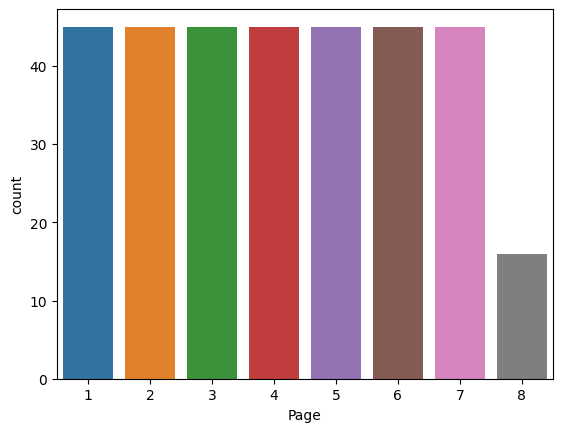

In [57]:
sns.countplot(x='Page', data=olx_df)

### **Price Distribution**

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


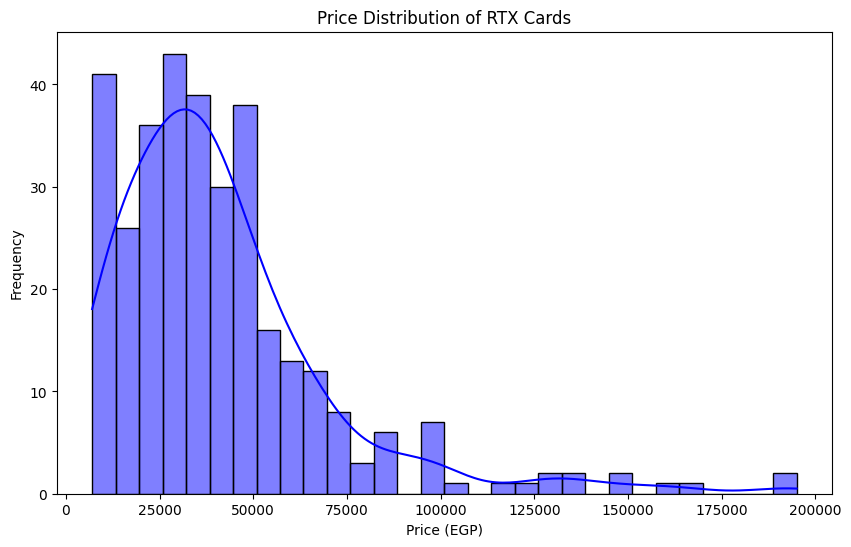

In [58]:
plt.figure(figsize=(10, 6))
sns.histplot(olx_df['Price'], kde=True, bins=30, color='blue')
plt.title('Price Distribution of RTX Cards')
plt.xlabel('Price (EGP)')
plt.ylabel('Frequency')
plt.show()

# Amazon Preprocessing and EDA

In [59]:
amazon_df

,Title,Price,Rating,Details Link,Image URL,Page
0,ASUS Dual GeForce RTX 4060 EVO OC Edition 8GB ...,"19,999.",4.7 out of 5 stars,https://www.amazon.eg/-/en/ASUS-DisplayPort-Ax...,https://m.media-amazon.com/images/I/817G0HRzaZ...,2
1,Gigabyte GeForce RTX 4090 Gaming OC 24G Graphi...,"175,779.",4.3 out of 5 stars,https://www.amazon.eg/-/en/Gigabyte-Graphics-W...,https://m.media-amazon.com/images/I/711vU2IrEu...,2
2,GIGABYTE GeForce RTX 4070 Super Eagle OC ICE 1...,"37,799.",4.4 out of 5 stars,https://www.amazon.eg/-/en/GIGABYTE-Graphics-W...,https://m.media-amazon.com/images/I/71DLBX0STx...,2
3,ASUS TUF Gaming GeForce RTX 4070 Ti SUPER 16 G...,"49,990.",4.3 out of 5 stars,https://www.amazon.eg/-/en/ASUS-TUF-RTX4070TIS...,https://m.media-amazon.com/images/I/61pRpUUnRR...,2
4,ASUS GeForce RTX 4060 DUAL EVO 8G OC Gaming Gr...,"22,999.",4.6 out of 5 stars,https://www.amazon.eg/-/en/ASUS-GeForce-4060-G...,https://m.media-amazon.com/images/I/817G0HRzaZ...,2
5,ASUS Dual GeForce RTX™ 3060 White OC Edition 8...,"20,459.",3.6 out of 5 stars,https://www.amazon.eg/-/en/GeForce-RTXTM-White...,https://m.media-amazon.com/images/I/71woZn5qSc...,2
6,MSI GeForce RTX 4070 Ti VENTUS 3X 12G OC Graph...,"79,479.",4.6 out of 5 stars,https://www.amazon.eg/-/en/MSI-GeForce-4070-VE...,https://m.media-amazon.com/images/I/81oBMA48NX...,2
7,Gigabyte GeForce RTX 4070 SUPER GAMING OC Grap...,N/A,4.6 out of 5 stars,https://www.amazon.eg/-/en/Gigabyte-GeForce-SU...,https://m.media-amazon.com/images/I/71BCWWe+dw...,2
8,AORUS GeForce RTX 4080 Super Master 16G,"115,400.",N/A,https://www.amazon.eg/-/en/AORUS-GeForce-4080-...,https://m.media-amazon.com/images/I/7199fFpV-u...,2
9,Gigabyte GeForce RTX 4070 Super Eagle OC ICE (...,"37,799.",4.7 out of 5 stars,https://www.amazon.eg/-/en/Gigabyte-GeForce-Ex...,https://m.media-amazon.com/images/I/71ry8Elh0E...,2


In [60]:
# Ensure 'Price' is treated as string and clean it
amazon_df['Price'] = (
    amazon_df['Price']
    .astype(str)  # Convert all values in 'Price' to string
    .str.replace(r'[^\d.]', '', regex=True)  # Remove all non-numeric characters except dots
    .str.strip()
)
amazon_df['Price'] = pd.to_numeric(amazon_df['Price'], errors='coerce')  # Convert to float, invalid entries to NaN

# Drop rows with missing or invalid 'Price'
amazon_df = amazon_df.dropna(subset=['Price'])

# Clean the rating column
amazon_df['Rating'] = amazon_df['Rating'].str.extract(r'(\d+\.\d+)').astype(float)

print("Done Cleaning")
amazon_df.head()

Done Cleaning


<ipython-input-60-372222e25446>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amazon_df['Rating'] = amazon_df['Rating'].str.extract(r'(\d+\.\d+)').astype(float)


,Title,Price,Rating,Details Link,Image URL,Page
0,ASUS Dual GeForce RTX 4060 EVO OC Edition 8GB ...,19999.0,4.7,https://www.amazon.eg/-/en/ASUS-DisplayPort-Ax...,https://m.media-amazon.com/images/I/817G0HRzaZ...,2
1,Gigabyte GeForce RTX 4090 Gaming OC 24G Graphi...,175779.0,4.3,https://www.amazon.eg/-/en/Gigabyte-Graphics-W...,https://m.media-amazon.com/images/I/711vU2IrEu...,2
2,GIGABYTE GeForce RTX 4070 Super Eagle OC ICE 1...,37799.0,4.4,https://www.amazon.eg/-/en/GIGABYTE-Graphics-W...,https://m.media-amazon.com/images/I/71DLBX0STx...,2
3,ASUS TUF Gaming GeForce RTX 4070 Ti SUPER 16 G...,49990.0,4.3,https://www.amazon.eg/-/en/ASUS-TUF-RTX4070TIS...,https://m.media-amazon.com/images/I/61pRpUUnRR...,2
4,ASUS GeForce RTX 4060 DUAL EVO 8G OC Gaming Gr...,22999.0,4.6,https://www.amazon.eg/-/en/ASUS-GeForce-4060-G...,https://m.media-amazon.com/images/I/817G0HRzaZ...,2


### Products in Pages

<Axes: xlabel='Page', ylabel='count'>

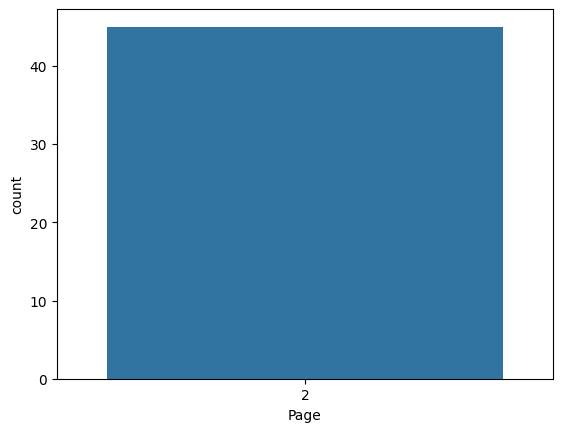

In [61]:
sns.countplot(x='Page', data=amazon_df)

### Price Distribution

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


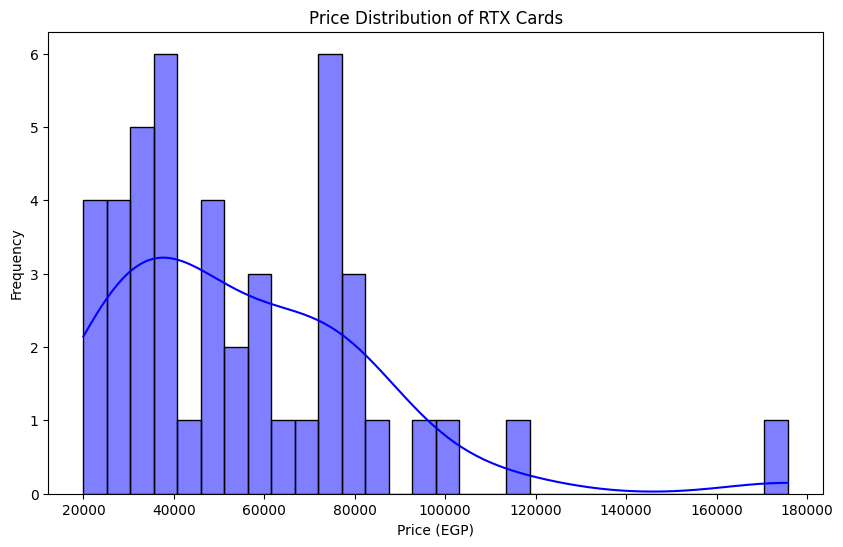

In [62]:
plt.figure(figsize=(10, 6))
sns.histplot(amazon_df['Price'], kde=True, bins=30, color='blue')
plt.title('Price Distribution of RTX Cards')
plt.xlabel('Price (EGP)')
plt.ylabel('Frequency')
plt.show()

### Rating Visualization (Distribution / Frequency)

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


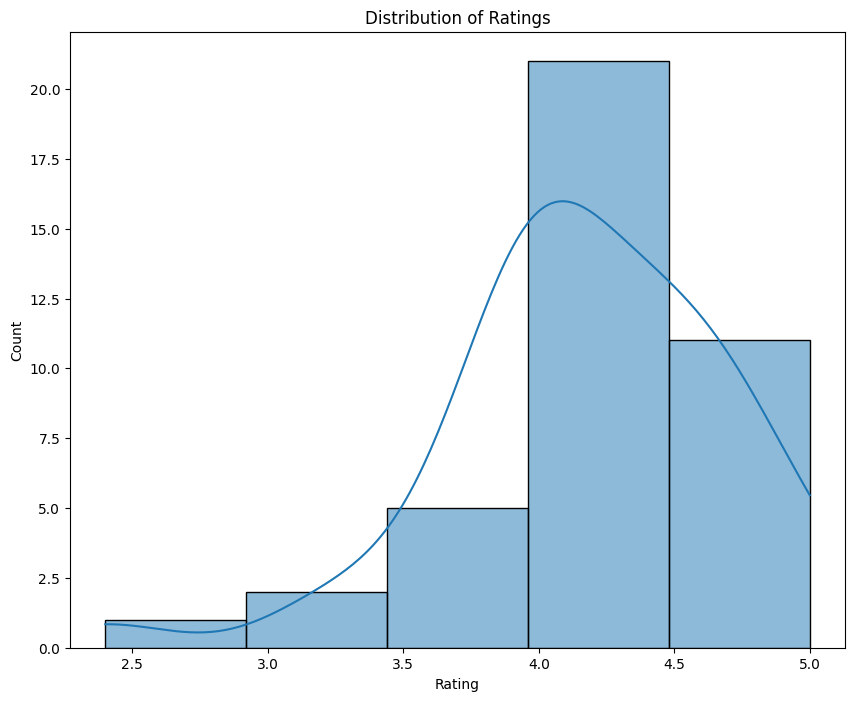

In [63]:
plt.figure(figsize=(10, 8))
sns.histplot(amazon_df['Rating'], bins=5, kde=True)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

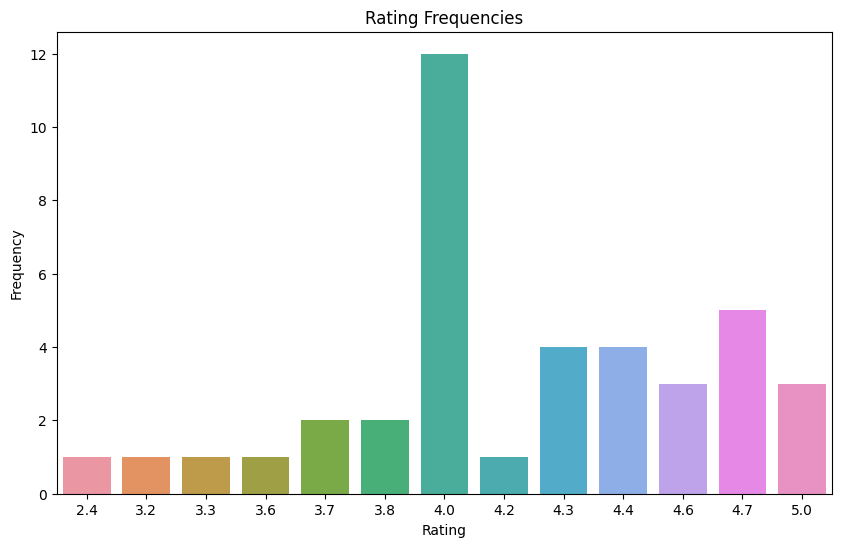

In [64]:
plt.figure(figsize=(10, 6))
rating_counts = amazon_df['Rating'].value_counts().sort_index()
sns.barplot(x=rating_counts.index, y=rating_counts.values)
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.title('Rating Frequencies')
plt.show()

# Sigma Store Preprocessing and EDA

In [65]:
sigma_df

,Title,Price,Rating,Details Link,Image URL,Page
0,"Lenovo Legion 5 Gaming Laptop - Ryzen 5-5600H,...","55,949.",4.0 out of 5 stars,https://www.amazon.eg/-/en/Lenovo-Legion-Gamin...,https://m.media-amazon.com/images/I/51XX3p1Kb2...,3
1,MSI Thin 15 B13UC|i7-13620H| RTX 3050 4GB| 16G...,"37,899.",N/A,https://www.amazon.eg/-/en/MSI-i7-13620H-3200M...,https://m.media-amazon.com/images/I/51+0kdRrlV...,3
2,Acer Nitro 17 Gaming Laptop | AMD Ryzen 7 7840...,"95,540.",4.0 out of 5 stars,https://www.amazon.eg/-/en/Octa-Core-GeForce-D...,https://m.media-amazon.com/images/I/711+0tgn+6...,3
3,"HP Victus Gaming Laptop (16-r0067ne), CPU: Cor...","73,614.",4.2 out of 5 stars,https://www.amazon.eg/-/en/HP-Victus-Gaming-La...,https://m.media-amazon.com/images/I/61MAXi8vbE...,3
4,"HP Envy 16 Touch - Intel Core i9-13900H, 64GB ...","108,139.",N/A,https://www.amazon.eg/-/en/HP-Envy-Touch-i9-13...,https://m.media-amazon.com/images/I/61GTJ0xfdR...,3
5,"Lenovo Legion 5 Gaming Laptop - Ryzen 5-5600H,...","47,301.",4.0 out of 5 stars,https://www.amazon.eg/-/en/Lenovo-Legion-Gamin...,https://m.media-amazon.com/images/I/51M5LTNoZ4...,3
6,"HP Victus Gaming Laptop (15-fa1011ne), CPU: Co...","52,789.",N/A,https://www.amazon.eg/-/en/HP-Victus-Gaming-La...,https://m.media-amazon.com/images/I/51aJyFw+Qv...,3
7,"Lenovo Legion 7 Gaming Laptop, 16"" WQXGA 165Hz...","73,879.",3.5 out of 5 stars,https://www.amazon.eg/-/en/Lenovo-Legion-3080_...,https://m.media-amazon.com/images/I/41SkIEjxCM...,3
8,Vibox II-95 Gaming PC - Six Core Intel i5 1040...,"67,000.",N/A,https://www.amazon.eg/-/en/Vibox-II-95-Gaming-...,https://m.media-amazon.com/images/I/71uHeXanoM...,3
9,Lenovo LOQ 15ARP9 Gaming Laptop - Ryzen 7 7435...,"52,489.",4.3 out of 5 stars,https://www.amazon.eg/-/en/Lenovo-LOQ-15ARP9-G...,https://m.media-amazon.com/images/I/61F9bJVMGK...,3


### Data Cleaning

In [66]:
# Ensure 'Price' is treated as string and clean it
sigma_df['Price'] = (
    sigma_df['Price']
    .astype(str)  # Convert all values in 'Price' to string
    .str.replace(r'[^\d.]', '', regex=True)  # Remove all non-numeric characters except dots
    .str.strip()
)
sigma_df['Price'] = pd.to_numeric(sigma_df['Price'], errors='coerce')  # Convert to float, invalid entries to NaN

# Drop rows with missing or invalid 'Price'
sigma_df = sigma_df.dropna(subset=['Price'])

# Clean the rating column
sigma_df['Rating'] = sigma_df['Rating'].str.extract(r'(\d+\.\d+)').astype(float)

print("Done Cleaning")
sigma_df.head()

Done Cleaning


/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Title,Price,Rating,Details Link,Image URL,Page
0,"Lenovo Legion 5 Gaming Laptop - Ryzen 5-5600H,...",55949.0,4.0,https://www.amazon.eg/-/en/Lenovo-Legion-Gamin...,https://m.media-amazon.com/images/I/51XX3p1Kb2...,3
1,MSI Thin 15 B13UC|i7-13620H| RTX 3050 4GB| 16G...,37899.0,NaN,https://www.amazon.eg/-/en/MSI-i7-13620H-3200M...,https://m.media-amazon.com/images/I/51+0kdRrlV...,3
2,Acer Nitro 17 Gaming Laptop | AMD Ryzen 7 7840...,95540.0,4.0,https://www.amazon.eg/-/en/Octa-Core-GeForce-D...,https://m.media-amazon.com/images/I/711+0tgn+6...,3
3,"HP Victus Gaming Laptop (16-r0067ne), CPU: Cor...",73614.0,4.2,https://www.amazon.eg/-/en/HP-Victus-Gaming-La...,https://m.media-amazon.com/images/I/61MAXi8vbE...,3
4,"HP Envy 16 Touch - Intel Core i9-13900H, 64GB ...",108139.0,NaN,https://www.amazon.eg/-/en/HP-Envy-Touch-i9-13...,https://m.media-amazon.com/images/I/61GTJ0xfdR...,3


### How Many Products in each Page

<Axes: xlabel='Page', ylabel='count'>

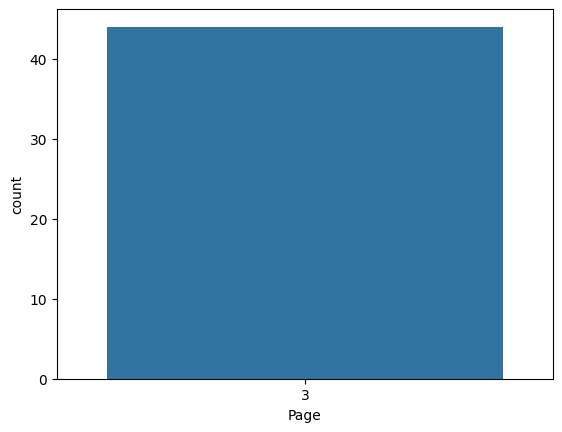

In [67]:
sns.countplot(x='Page', data=sigma_df)

### Price Distribution

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


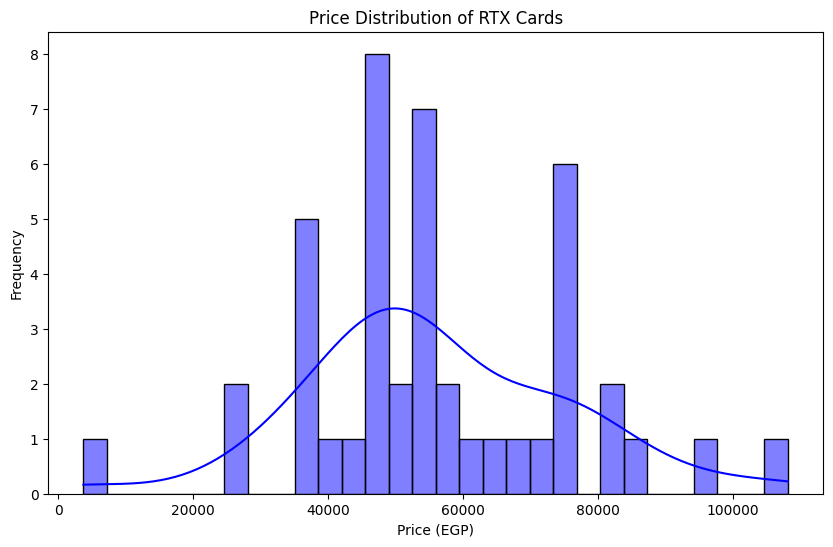

In [68]:
plt.figure(figsize=(10, 6))
sns.histplot(sigma_df['Price'], kde=True, bins=30, color='blue')
plt.title('Price Distribution of RTX Cards')
plt.xlabel('Price (EGP)')
plt.ylabel('Frequency')
plt.show()

### Distribution of Ratings

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


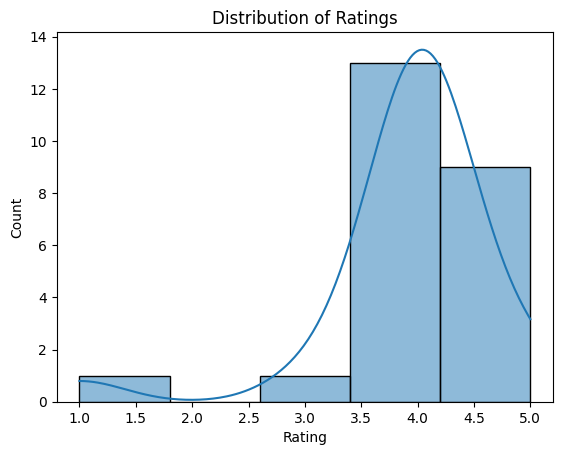

In [69]:
sns.histplot(sigma_df['Rating'], bins=5, kde=True)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

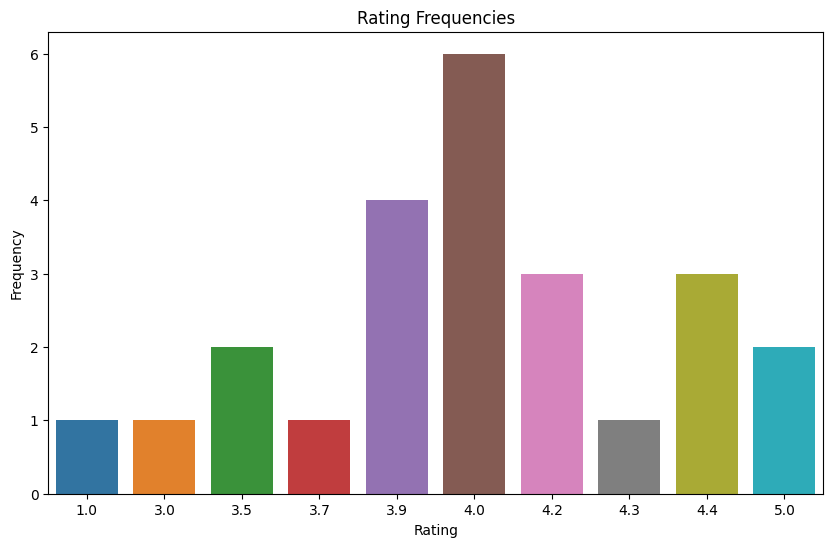

In [70]:
plt.figure(figsize=(10, 6))
rating_counts = sigma_df['Rating'].value_counts().sort_index()
sns.barplot(x=rating_counts.index, y=rating_counts.values)
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.title('Rating Frequencies')
plt.show()

# Output results into separate CSV files

In [71]:
olx_df.to_csv('olx.csv', index=False)  
amazon_df.to_csv('amazon.csv', index=False)  
sigma_df.to_csv('sigma.csv', index=False)  

# What Store should I do next? (leave it in the comments)